In [1]:
import matplotlib.pyplot as plt
from qiskit.circuit import ParameterVector
from qiskit.circuit import Parameter
from qiskit import QuantumCircuit
from qiskit.circuit.library import RYGate
from scipy.ndimage import label

In [2]:
def testf(ab: dict):
    ab["abd"] = 123


a = {"a": 1, "b": 2, "c": 3}
testf(a)
a

{'a': 1, 'b': 2, 'c': 3, 'abd': 123}

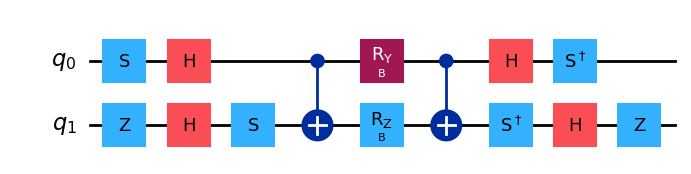

In [3]:


qc = QuantumCircuit(2, name="$R_{XY+YX}$")
b = Parameter('B')
qc.z(1)
qc.s(0)
qc.h(1)
qc.h(0)
qc.s(1)
qc.cx(0, 1)
qc.ry(b, 0)
qc.rz(b, 1)
qc.cx(0, 1)
qc.h(0)
qc.sdg(1)
qc.sdg(0)
qc.h(1)
qc.z(1)
base_gate = qc.to_gate(label="$R_{XY+YX}$")
qc.draw("mpl")

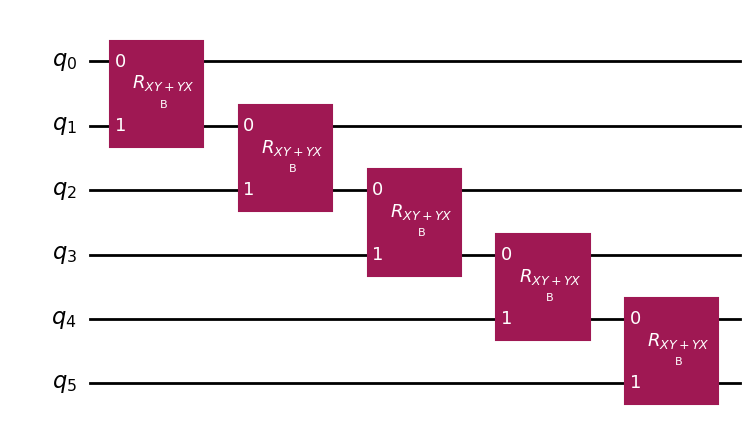

In [4]:
mqc = QuantumCircuit(6)
my_params = ParameterVector("A", 5)
# base_gate = RYGate(Parameter("C"))
for i in range(5):
    temp_qc = QuantumCircuit(2)
    temp_qc.append(base_gate.copy(), [0, 1])
    temp_qc.assign_parameters([my_params[i]])
    gate = temp_qc.to_gate(label=base_gate.name)
    # gate = base_gate.copy()
    # gate.params[0] = my_params[i]
    # gate = qc.to_gate(label="$R_{XY+YX}$", parameter_map={qc.parameters[0]: my_params[i]})
    mqc.append(gate, [i, i + 1])
mqc.draw("mpl")

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29]
0


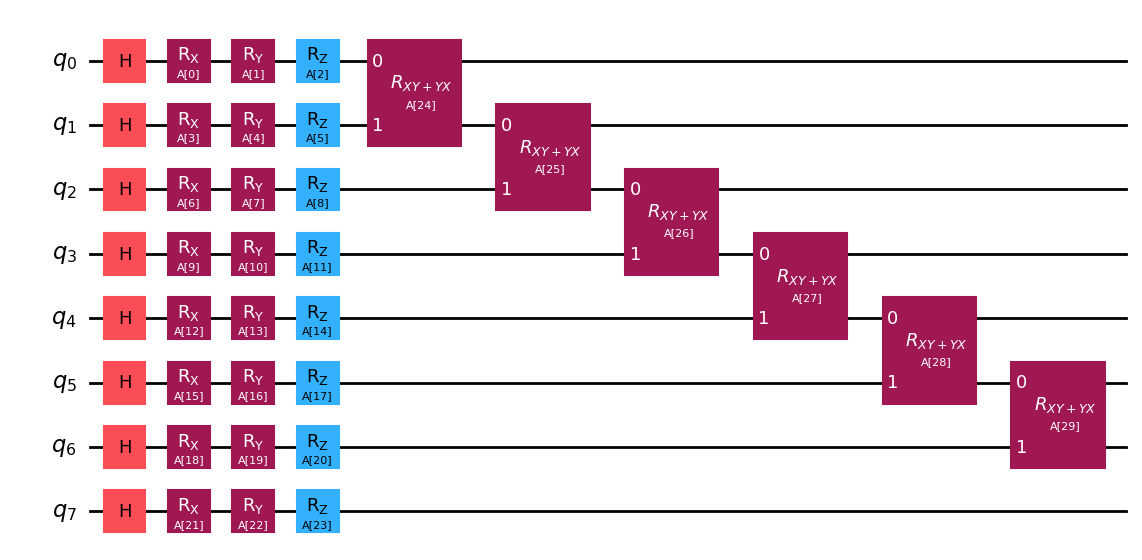

In [5]:
from solver.circuits import YXPlusXYRYAdaptAnsatz1, HardwareAdaptAnsatz1
import random

li = random.sample(range(0, 15), 15)
li = list(range(0, 30))
# li.insert(4, 25)
print(li)
temp = HardwareAdaptAnsatz1(8)
print(temp.set_ansatz(li))
circ = temp()
circ.draw("mpl")

In [6]:
circ.parameters

ParameterView([ParameterVectorElement(A[0]), ParameterVectorElement(A[1]), ParameterVectorElement(A[2]), ParameterVectorElement(A[3]), ParameterVectorElement(A[4]), ParameterVectorElement(A[5]), ParameterVectorElement(A[6]), ParameterVectorElement(A[7]), ParameterVectorElement(A[8]), ParameterVectorElement(A[9]), ParameterVectorElement(A[10]), ParameterVectorElement(A[11]), ParameterVectorElement(A[12]), ParameterVectorElement(A[13]), ParameterVectorElement(A[14]), ParameterVectorElement(A[15]), ParameterVectorElement(A[16]), ParameterVectorElement(A[17]), ParameterVectorElement(A[18]), ParameterVectorElement(A[19]), ParameterVectorElement(A[20]), ParameterVectorElement(A[21]), ParameterVectorElement(A[22]), ParameterVectorElement(A[23]), ParameterVectorElement(A[24]), ParameterVectorElement(A[25]), ParameterVectorElement(A[26]), ParameterVectorElement(A[27]), ParameterVectorElement(A[28]), ParameterVectorElement(A[29])])

In [7]:
circ.draw("text")

┌───┐ ┌──────────┐ ┌──────────┐ ┌──────────┐┌─────────────────────┐»
q_0: ┤ H ├─┤ Rx(A[0]) ├─┤ Ry(A[1]) ├─┤ Rz(A[2]) ├┤0                    ├»
     ├───┤ ├──────────┤ ├──────────┤ ├──────────┤│  $R_{XY+YX}$(A[24]) │»
q_1: ┤ H ├─┤ Rx(A[3]) ├─┤ Ry(A[4]) ├─┤ Rz(A[5]) ├┤1                    ├»
     ├───┤ ├──────────┤ ├──────────┤ ├──────────┤└─────────────────────┘»
q_2: ┤ H ├─┤ Rx(A[6]) ├─┤ Ry(A[7]) ├─┤ Rz(A[8]) ├───────────────────────»
     ├───┤ ├──────────┤┌┴──────────┤┌┴──────────┤                       »
q_3: ┤ H ├─┤ Rx(A[9]) ├┤ Ry(A[10]) ├┤ Rz(A[11]) ├───────────────────────»
     ├───┤┌┴──────────┤├───────────┤├───────────┤                       »
q_4: ┤ H ├┤ Rx(A[12]) ├┤ Ry(A[13]) ├┤ Rz(A[14]) ├───────────────────────»
     ├───┤├───────────┤├───────────┤├───────────┤                       »
q_5: ┤ H ├┤ Rx(A[15]) ├┤ Ry(A[16]) ├┤ Rz(A[17]) ├───────────────────────»
     ├───┤├───────────┤├───────────┤├───────────┤                       »
q_6: ┤ H ├┤ Rx(A[18]) ├┤ Ry(A[19]) ├┤ Rz(A[20]) ├───────────────────────»
     ├───┤├───────────┤├───────────┤├───────────┤                       »
q_7: ┤ H ├┤ Rx(A[21]) ├┤ Ry(A[22]) ├┤ Rz(A[23]) ├───────────────────────»
     └───┘└───────────┘└───────────┘└───────────┘                       »
«                                                                          »
«q_0: ─────────────────────────────────────────────────────────────────────»
«     ┌─────────────────────┐                                              »
«q_1: ┤0                    ├──────────────────────────────────────────────»
«     │  $R_{XY+YX}$(A[25]) │┌─────────────────────┐                       »
«q_2: ┤1                    ├┤0                    ├───────────────────────»
«     └─────────────────────┘│  $R_{XY+YX}$(A[26]) │┌─────────────────────┐»
«q_3: ───────────────────────┤1                    ├┤0                    ├»
«                            └─────────────────────┘│  $R_{XY+YX}$(A[27]) │»
«q_4: ──────────────────────────────────────────────┤1                    ├»
«                                                   └─────────────────────┘»
«q_5: ─────────────────────────────────────────────────────────────────────»
«                                                                          »
«q_6: ─────────────────────────────────────────────────────────────────────»
«                                                                          »
«q_7: ─────────────────────────────────────────────────────────────────────»
«                                                                          »
«                                                   
«q_0: ──────────────────────────────────────────────
«                                                   
«q_1: ──────────────────────────────────────────────
«                                                   
«q_2: ──────────────────────────────────────────────
«                                                   
«q_3: ──────────────────────────────────────────────
«     ┌─────────────────────┐                       
«q_4: ┤0                    ├───────────────────────
«     │  $R_{XY+YX}$(A[28]) │┌─────────────────────┐
«q_5: ┤1                    ├┤0                    ├
«     └─────────────────────┘│  $R_{XY+YX}$(A[29]) │
«q_6: ───────────────────────┤1                    ├
«                            └─────────────────────┘
«q_7: ──────────────────────────────────────────────
«

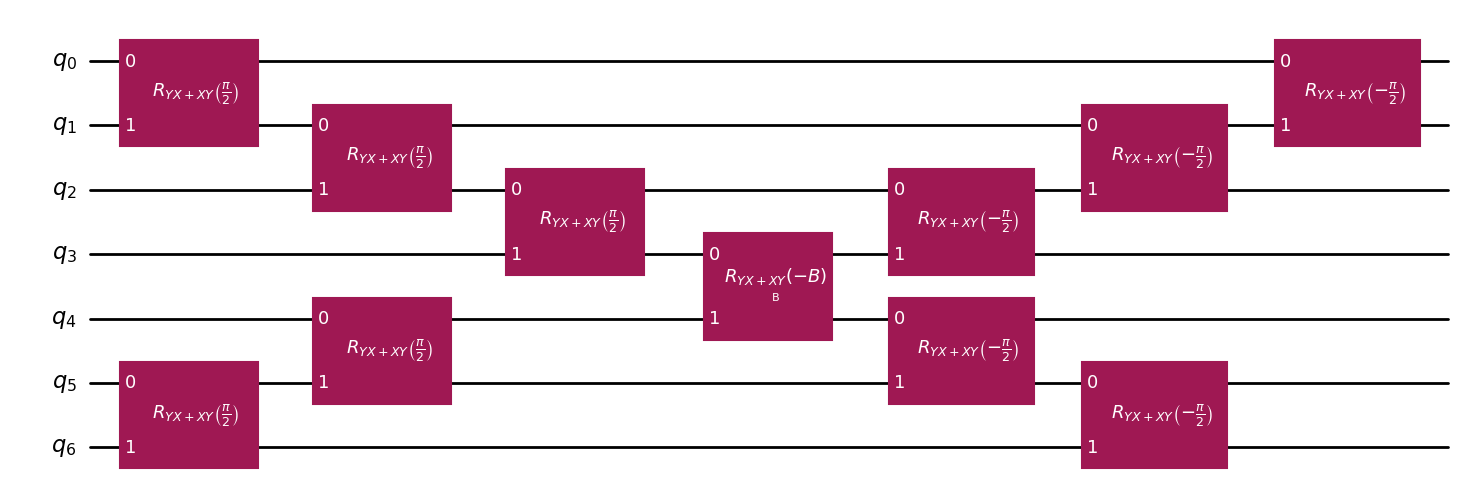

In [2]:
import sys

sys.path.insert(1, '..')
import importlib
from solver import circuits

qc = circuits.build_r_xzy_m_yzx(Parameter('B'), 5)
qc.draw("mpl")
pass

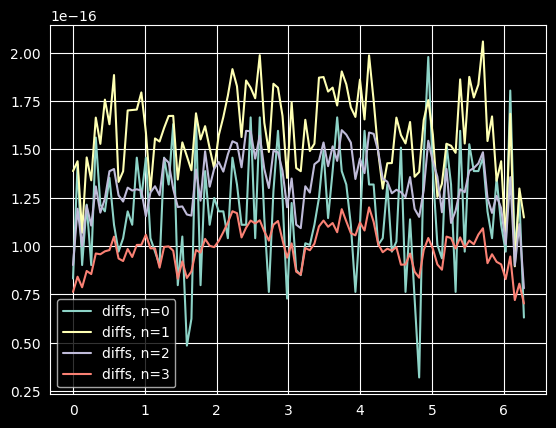

In [3]:
import numpy as np
from scipy.linalg import expm
from qiskit.quantum_info import Operator
import matplotlib.pyplot as plt

x = np.array([[0, 1], [1, 0]])
y = np.array([[0, -1j], [1j, 0]])
z = np.array([[1, 0], [0, -1]])

def get_dense_matrix(n=0):
    result1 = x
    result2 = y
    for i in range(n):
        result1 = np.kron(result1, z)
        result2 = np.kron(result2, z)
    result1 = np.kron(result1, y)
    result2 = np.kron(result2, x)
    return -(result1 - result2)/2. # the extra - is here to compensate for qiskits qubit ordering when taking the tensor product

for n in range(4):
    xy = get_dense_matrix(n)
    theta_vals = np.linspace(0, 2*np.pi, 100)
    matrices1 = [expm(1j*t*xy) for t in theta_vals]
    matrices2 = [Operator(circuits.build_r_xzy_m_yzx(t, n)).to_matrix() for t in theta_vals]
    diffs = [np.abs(m1-m2).mean() for m1, m2 in zip(matrices1, matrices2)]
    plt.plot(theta_vals, diffs, label=f"diffs, n={n}")
# plt.plot(theta_vals, [np.real(m1[2,1]) for m1 in matrices1], label="m1")
# plt.plot(theta_vals, [np.real(m2[2,1]) for m2 in matrices2], label="m2")
plt.legend()
plt.show()

In [4]:
qc = QuantumCircuit(2)
qc.z(0)
qc.x(1)
Operator(qc).to_matrix()

array([[ 0.+0.j,  0.+0.j,  1.+0.j,  0.+0.j],
       [ 0.+0.j,  0.+0.j,  0.+0.j, -1.+0.j],
       [ 1.+0.j,  0.+0.j,  0.+0.j,  0.+0.j],
       [ 0.+0.j, -1.+0.j,  0.+0.j,  0.+0.j]])